# Input Clustering Analysis for Ensemble Winners

This notebook asks a sharper question than the original greedy-merit notebook:

1. Do different ensemble members win in different parts of input space?
2. If the plots look mixed, can we quantify that instead of eyeballing it?

The workflow here is:

- load checkpoints and the shared optimization problem,
- compute per-sample merit for each member,
- assign a winning member to each test input,
- visualize winners in PCA first, then optional `t-SNE` / `UMAP`,
- measure whether winner identity is predictable from `x` using a simple classifier,
- measure nearest-neighbor winner consistency.

Interpretation guideline:

- strong spatial structure means winners should cluster visually **and** be somewhat predictable from `x`,
- weak structure means mixed plots, low classifier accuracy, and low local winner consistency.

In [1]:
import os
import sys
import glob
import yaml
import torch
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter
from matplotlib.colors import ListedColormap

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix
from sklearn.neighbors import NearestNeighbors

try:
    from sklearn.manifold import TSNE
    HAS_TSNE = True
except Exception:
    HAS_TSNE = False

try:
    import umap
    HAS_UMAP = True
except Exception:
    HAS_UMAP = False

sys.path.insert(0, os.getcwd())

from eval import resolve_checkpoints, load_single_model
from utils.trainer import load_instance, DEVICE
from utils.evaluator import Evaluator

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.grid'] = True


/home/khain/.conda/envs/ml4opt/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configure

Set either `RUN_DIR` or `CKPT_PATHS`. If both are set, `CKPT_PATHS` wins.


In [28]:
# --- edit this cell ---
CKPT_PATHS = None

# RUN_DIR = "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260315-172824_FSNet_seed0_e300_lr1e-04_n7000_ens5_vanilla_pre"    
# RUN_DIR = "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260315-174003_FSNet_seed100_e300_lr1e-04_n7000_ens5_vanilla_pre"  
RUN_DIR = "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260316-003057_FSNet_seed2025_e300_lr1e-04_n7000_ens5_vanilla_pre" 

# RUN_DIR = "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260316-003102_penalty_seed0_e1000_lr1e-04_n7000_ens5_vanilla_pre" 
# RUN_DIR = "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260316-004753_penalty_seed100_e1000_lr1e-04_n7000_ens5_vanilla_pre" 
# RUN_DIR = "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260316-010442_penalty_seed2025_e1000_lr1e-04_n7000_ens5_vanilla_pre"

BATCH_SIZE = 512
MERIT_EQ_WEIGHT = 1e5
MERIT_INEQ_WEIGHT = 1e5

USE_TSNE = True
USE_UMAP = True
EMBED_MAX_POINTS = 2000
TSNE_PERPLEXITY = 30
RANDOM_STATE = 0


## 2. Load problem and member checkpoints

In [29]:
if CKPT_PATHS is None:
    checkpoints = resolve_checkpoints(RUN_DIR)
else:
    checkpoints = CKPT_PATHS

print(f"Found {len(checkpoints)} checkpoints")
for i, p in enumerate(checkpoints):
    print(f"  [{i}] {p}")

first_ckpt = torch.load(checkpoints[0], map_location='cpu', weights_only=False)
config = first_ckpt['config']
method = config['method']

opt_problem, _ = load_instance(config)
evaluator = Evaluator(opt_problem, method, config)

members = []
for ckpt_path in checkpoints:
    model, _ = load_single_model(ckpt_path, opt_problem)
    model.eval()
    members.append(model)

n_members = len(members)
print(f"Loaded {n_members} members on device: {DEVICE}")
print(f"Problem: {config['prob_type']}/{config['prob_name']}  method={method}")


Found 5 checkpoints
  [0] results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260316-003057_FSNet_seed2025_e300_lr1e-04_n7000_ens5_vanilla_pre/members/member_0.pt
  [1] results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260316-003057_FSNet_seed2025_e300_lr1e-04_n7000_ens5_vanilla_pre/members/member_1.pt
  [2] results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260316-003057_FSNet_seed2025_e300_lr1e-04_n7000_ens5_vanilla_pre/members/member_2.pt
  [3] results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260316-003057_FSNet_seed2025_e300_lr1e-04_n7000_ens5_vanilla_pre/members/member_3.pt
  [4] results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260316-003057_FSNet_seed2025_e300_lr1e-04_n7000_ens5_vanilla_pre/members/member_4.pt
Loaded 5 members on device: cpu
Problem: nonsmooth_nonconvex/socp  method=FSNet


## 3. Compute per-sample merit, objective, and winner labels

In [30]:
@torch.no_grad()
def evaluate_member_arrays(model, dataset, batch_size=256):
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False)

    objs = []
    eqs = []
    ineqs = []

    for X_batch, _Y_true in loader:
        X_batch = X_batch.to(DEVICE)
        Y_final = evaluator._get_final_prediction(model, X_batch)

        obj = opt_problem.obj_fn(Y_final).detach().cpu().numpy()
        eq = opt_problem.eq_resid(X_batch, Y_final).abs().sum(dim=1).detach().cpu().numpy()
        ineq = opt_problem.ineq_resid(X_batch, Y_final).abs().sum(dim=1).detach().cpu().numpy()

        objs.append(obj)
        eqs.append(eq)
        ineqs.append(ineq)

    obj = np.concatenate(objs)
    eq = np.concatenate(eqs)
    ineq = np.concatenate(ineqs)
    merit = obj + MERIT_EQ_WEIGHT * eq + MERIT_INEQ_WEIGHT * ineq
    return obj, eq, ineq, merit

all_objs = []
all_eqs = []
all_ineqs = []
all_merits = []

for i, member in enumerate(members):
    obj, eq, ineq, merit = evaluate_member_arrays(member, opt_problem.test_dataset, batch_size=BATCH_SIZE)
    all_objs.append(obj)
    all_eqs.append(eq)
    all_ineqs.append(ineq)
    all_merits.append(merit)
    print(f"Member {i}: mean merit={merit.mean():.6e}")

objs = np.stack(all_objs, axis=0)
eqs = np.stack(all_eqs, axis=0)
ineqs = np.stack(all_ineqs, axis=0)
merits = np.stack(all_merits, axis=0)

winner = merits.argmin(axis=0)
best_merit = merits.min(axis=0)
sorted_merits = np.sort(merits, axis=0)
margin_best_vs_second = sorted_merits[1] - sorted_merits[0]

win_counts = Counter(winner.tolist())
print("\nWin counts:")
for m in range(n_members):
    c = win_counts.get(m, 0)
    print(f"  Member {m}: {c:4d} / {winner.size} ({100*c/winner.size:5.2f}%)")

overall_best_member = merits.mean(axis=1).argmin()
print(f"\nBest single member by mean merit: Member {overall_best_member}")
print(f"Mean winner margin (second best - best): {margin_best_vs_second.mean():.6e}")


Member 0: mean merit=2.209394e+01
Member 1: mean merit=3.211486e+01
Member 2: mean merit=5.208367e+01
Member 3: mean merit=2.158730e+01
Member 4: mean merit=2.406045e+01

Win counts:
  Member 0:  600 / 2000 (30.00%)
  Member 1:    0 / 2000 ( 0.00%)
  Member 2:    8 / 2000 ( 0.40%)
  Member 3: 1321 / 2000 (66.05%)
  Member 4:   71 / 2000 ( 3.55%)

Best single member by mean merit: Member 3
Mean winner margin (second best - best): 1.665825e+00


## 4. Build input features and embeddings

In [31]:
X_test = opt_problem.test_dataset.tensors[0].detach().cpu().numpy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_test)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print("PCA explained variance ratio:", pca.explained_variance_ratio_)

embed_idx = np.arange(len(X_test))
if len(X_test) > EMBED_MAX_POINTS:
    rng = np.random.default_rng(RANDOM_STATE)
    embed_idx = np.sort(rng.choice(len(X_test), size=EMBED_MAX_POINTS, replace=False))

X_embed = X_scaled[embed_idx]
winner_embed = winner[embed_idx]
margin_embed = margin_best_vs_second[embed_idx]

X_tsne = None
if USE_TSNE:
    if not HAS_TSNE:
        print('TSNE unavailable in current environment')
    else:
        tsne = TSNE(
            n_components=2,
            perplexity=TSNE_PERPLEXITY,
            init='pca',
            learning_rate='auto',
            random_state=RANDOM_STATE,
        )
        X_tsne = tsne.fit_transform(X_embed)

X_umap = None
if USE_UMAP:
    if not HAS_UMAP:
        print('UMAP unavailable; install umap-learn if you want it')
    else:
        reducer = umap.UMAP(n_components=2, random_state=RANDOM_STATE)
        X_umap = reducer.fit_transform(X_embed)


PCA explained variance ratio: [0.02606779 0.02567235]


/home/khain/.conda/envs/ml4opt/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## 5. Visualize winner labels in embedding space

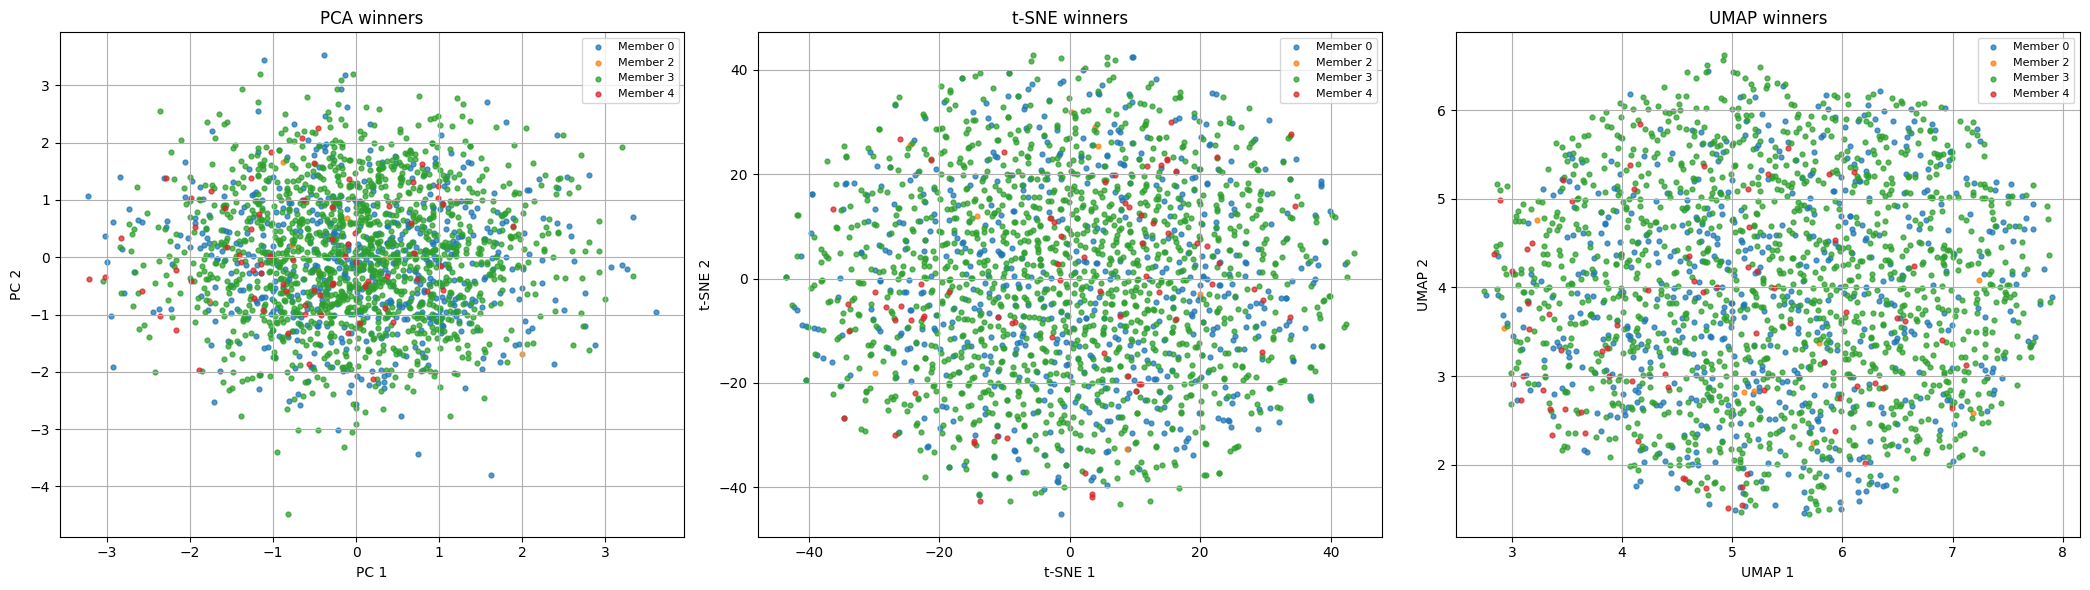

In [32]:
def plot_labels(ax, emb, labels, title, xlabel, ylabel):
    unique_labels = np.unique(labels)
    cmap = plt.colormaps['tab10']
    for i, member_id in enumerate(unique_labels):
        mask = labels == member_id
        ax.scatter(emb[mask, 0], emb[mask, 1], s=12, alpha=0.75, color=cmap(i), label=f'Member {member_id}')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

panels = [('PCA winners', X_pca, winner, 'PC 1', 'PC 2')]
if X_tsne is not None:
    panels.append(('t-SNE winners', X_tsne, winner_embed, 't-SNE 1', 't-SNE 2'))
if X_umap is not None:
    panels.append(('UMAP winners', X_umap, winner_embed, 'UMAP 1', 'UMAP 2'))

fig, axes = plt.subplots(1, len(panels), figsize=(7 * len(panels), 6), squeeze=False)
for ax, (title, emb, labels, xlabel, ylabel) in zip(axes[0], panels):
    plot_labels(ax, emb, labels, title, xlabel, ylabel)
plt.tight_layout()
plt.show()


## 6. Visualize winner confidence

If there really are regions, we often expect not only different colors but also places where the winner is clearly better than the runner-up. This cell colors points by the winner margin.


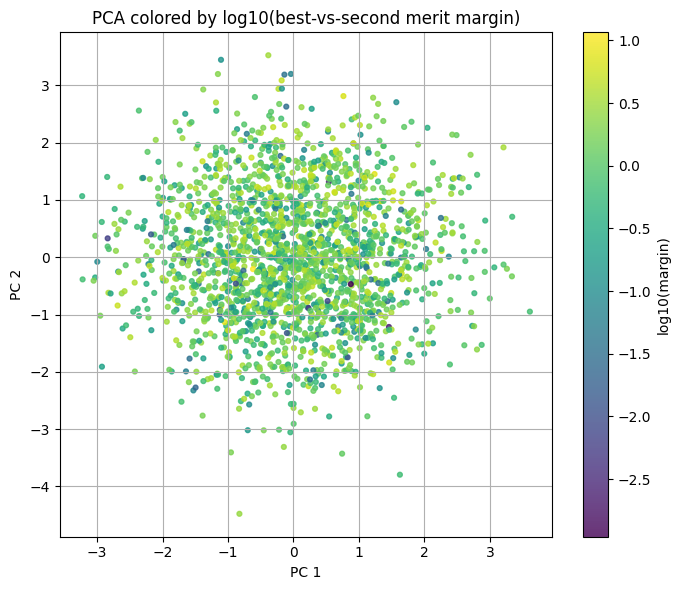

Margin summary:
  mean   = 1.665825e+00
  median = 1.244538e+00
  p90    = 3.667677e+00
  p99    = 5.802866e+00


In [33]:
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=np.log10(np.maximum(margin_best_vs_second, 1e-12)), s=12, cmap='viridis', alpha=0.8)
ax.set_title('PCA colored by log10(best-vs-second merit margin)')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
plt.colorbar(sc, ax=ax, label='log10(margin)')
plt.tight_layout()
plt.show()

print('Margin summary:')
print(f"  mean   = {margin_best_vs_second.mean():.6e}")
print(f"  median = {np.median(margin_best_vs_second):.6e}")
print(f"  p90    = {np.quantile(margin_best_vs_second, 0.90):.6e}")
print(f"  p99    = {np.quantile(margin_best_vs_second, 0.99):.6e}")


## 7. Quantify predictability: can `x -> winner` be learned?

This is a simple baseline, not a final scientific model. If even a linear classifier with standardized inputs can predict the winner better than chance, that suggests some winner structure is present in input space.


In [34]:
X_train, X_val, y_train, y_val = train_test_split(
    X_test, winner, test_size=0.30, random_state=RANDOM_STATE, stratify=winner
)

clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, multi_class='auto', random_state=RANDOM_STATE)
)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_val)

acc = accuracy_score(y_val, y_pred)
bal_acc = balanced_accuracy_score(y_val, y_pred)
majority_baseline = max(np.mean(y_val == m) for m in np.unique(y_val))
chance_baseline = 1.0 / len(np.unique(winner))

print('Winner-prediction accuracy from raw x:')
print(f"  accuracy            = {acc:.4f}")
print(f"  balanced accuracy   = {bal_acc:.4f}")
print(f"  majority baseline   = {majority_baseline:.4f}")
print(f"  uniform chance      = {chance_baseline:.4f}")

cm = confusion_matrix(y_val, y_pred, labels=np.arange(n_members))
print('\nConfusion matrix (rows=true, cols=pred):')
print(cm)


Winner-prediction accuracy from raw x:
  accuracy            = 0.7367
  balanced accuracy   = 0.4667
  majority baseline   = 0.6600
  uniform chance      = 0.2500

Confusion matrix (rows=true, cols=pred):
[[ 84   0   0  91   5]
 [  0   0   0   0   0]
 [  2   0   0   0   1]
 [ 47   0   0 347   2]
 [  4   0   0   6  11]]


/home/khain/.conda/envs/ml4opt/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## 8. Quantify local structure: nearest-neighbor winner consistency

If winner identity forms local regions, a point's nearest neighbors should often share its winner label.


Nearest-neighbor same-winner rate (K=10): 0.5793
Global majority-win fraction:              0.6605


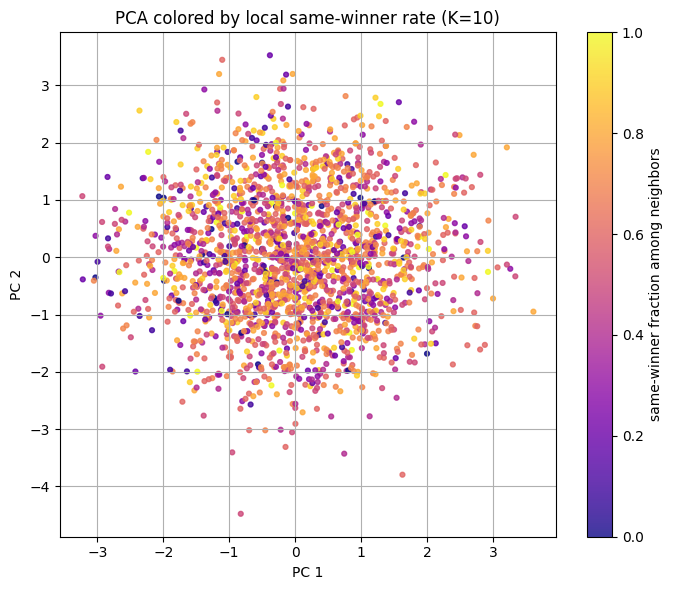

In [35]:
K = 10
nbrs = NearestNeighbors(n_neighbors=K + 1).fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# drop self-neighbor at position 0
neighbor_idx = indices[:, 1:]
neighbor_labels = winner[neighbor_idx]

same_label_rate_per_point = (neighbor_labels == winner[:, None]).mean(axis=1)
global_same_label_rate = same_label_rate_per_point.mean()
majority_win_rate = max(np.mean(winner == m) for m in np.unique(winner))

print(f'Nearest-neighbor same-winner rate (K={K}): {global_same_label_rate:.4f}')
print(f'Global majority-win fraction:              {majority_win_rate:.4f}')

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=same_label_rate_per_point, s=12, cmap='plasma', alpha=0.8)
ax.set_title(f'PCA colored by local same-winner rate (K={K})')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
plt.colorbar(sc, ax=ax, label='same-winner fraction among neighbors')
plt.tight_layout()
plt.show()


## 9. Quick interpretation checklist

Use the outputs above like this:

- If the winner plots are visually mixed, classifier accuracy is near the majority baseline, and NN consistency is only slightly above the global majority fraction, then there is probably **no strong input-region clustering**.
- If plots show separation and the classifier beats baseline meaningfully, that supports winner structure in input space.
- If plots look mixed but classifier accuracy is still decent, the structure may be high-dimensional and not visible in 2D.
- If the winner margin is tiny almost everywhere, then winner identity may simply be unstable or weakly specialized.


## 10. Analyze winners using problem-derived quantities

Instead of asking whether winners separate in raw input space, this section asks whether winners differ on optimization-related signals such as:

- raw objective before post-processing,
- raw equality / inequality violation,
- final objective and final violation,
- amount of post-processing movement (`||y_final - y_raw||`),
- ensemble disagreement on an instance,
- hardness of an instance as measured by the best achievable merit across members.

This is often more informative than PCA on `x` when winner regions are not obvious.

In [36]:
@torch.no_grad()
def evaluate_member_diagnostics(model, dataset, batch_size=256):
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False)

    raw_obj_list = []
    raw_eq_list = []
    raw_ineq_list = []
    raw_merit_list = []

    final_obj_list = []
    final_eq_list = []
    final_ineq_list = []
    final_merit_list = []

    move_l2_list = []
    move_linf_list = []

    for X_batch, _Y_true in loader:
        X_batch = X_batch.to(DEVICE)

        Y_raw = model(X_batch)
        Y_raw_scaled = opt_problem.scale(Y_raw)
        Y_final = evaluator._post_process_predictions(X_batch, Y_raw_scaled)

        raw_obj = opt_problem.obj_fn(Y_raw_scaled)
        raw_eq = opt_problem.eq_resid(X_batch, Y_raw_scaled).abs().sum(dim=1)
        raw_ineq = opt_problem.ineq_resid(X_batch, Y_raw_scaled).abs().sum(dim=1)
        raw_merit = raw_obj + MERIT_EQ_WEIGHT * raw_eq + MERIT_INEQ_WEIGHT * raw_ineq

        final_obj = opt_problem.obj_fn(Y_final)
        final_eq = opt_problem.eq_resid(X_batch, Y_final).abs().sum(dim=1)
        final_ineq = opt_problem.ineq_resid(X_batch, Y_final).abs().sum(dim=1)
        final_merit = final_obj + MERIT_EQ_WEIGHT * final_eq + MERIT_INEQ_WEIGHT * final_ineq

        move = Y_final - Y_raw_scaled
        move_l2 = torch.linalg.norm(move, dim=1)
        move_linf = move.abs().max(dim=1).values

        raw_obj_list.append(raw_obj.detach().cpu().numpy())
        raw_eq_list.append(raw_eq.detach().cpu().numpy())
        raw_ineq_list.append(raw_ineq.detach().cpu().numpy())
        raw_merit_list.append(raw_merit.detach().cpu().numpy())

        final_obj_list.append(final_obj.detach().cpu().numpy())
        final_eq_list.append(final_eq.detach().cpu().numpy())
        final_ineq_list.append(final_ineq.detach().cpu().numpy())
        final_merit_list.append(final_merit.detach().cpu().numpy())

        move_l2_list.append(move_l2.detach().cpu().numpy())
        move_linf_list.append(move_linf.detach().cpu().numpy())

    out = {
        'raw_obj': np.concatenate(raw_obj_list),
        'raw_eq': np.concatenate(raw_eq_list),
        'raw_ineq': np.concatenate(raw_ineq_list),
        'raw_merit': np.concatenate(raw_merit_list),
        'final_obj': np.concatenate(final_obj_list),
        'final_eq': np.concatenate(final_eq_list),
        'final_ineq': np.concatenate(final_ineq_list),
        'final_merit': np.concatenate(final_merit_list),
        'move_l2': np.concatenate(move_l2_list),
        'move_linf': np.concatenate(move_linf_list),
    }
    return out

member_diag = []
for i, member in enumerate(members):
    diag = evaluate_member_diagnostics(member, opt_problem.test_dataset, batch_size=BATCH_SIZE)
    member_diag.append(diag)
    print(
        f"Member {i}: raw_eq={diag['raw_eq'].mean():.3e}, raw_ineq={diag['raw_ineq'].mean():.3e}, "
        f"move_l2={diag['move_l2'].mean():.3e}, final_merit={diag['final_merit'].mean():.3e}"
    )


Member 0: raw_eq=2.774e+00, raw_ineq=3.977e-01, move_l2=1.391e-01, final_merit=2.209e+01
Member 1: raw_eq=2.390e+00, raw_ineq=4.298e-01, move_l2=1.275e-01, final_merit=3.211e+01
Member 2: raw_eq=8.713e+00, raw_ineq=9.495e-01, move_l2=3.522e-01, final_merit=5.208e+01
Member 3: raw_eq=8.302e+00, raw_ineq=4.224e-01, move_l2=3.003e-01, final_merit=2.159e+01
Member 4: raw_eq=2.645e+00, raw_ineq=3.453e-01, move_l2=1.302e-01, final_merit=2.406e+01


In [37]:
diag_names = list(member_diag[0].keys())
diag_arrays = {name: np.stack([d[name] for d in member_diag], axis=0) for name in diag_names}

winner_diag_summary = {}
for name, arr in diag_arrays.items():
    winner_values = arr[winner, np.arange(arr.shape[1])]
    winner_diag_summary[name] = winner_values

# instance-level hardness / disagreement features
instance_features = {
    'best_final_merit': merits.min(axis=0),
    'mean_final_merit': merits.mean(axis=0),
    'std_final_merit': merits.std(axis=0),
    'range_final_merit': merits.max(axis=0) - merits.min(axis=0),
    'winner_margin': margin_best_vs_second,
    'winner_move_l2': diag_arrays['move_l2'][winner, np.arange(len(winner))],
    'winner_raw_eq': diag_arrays['raw_eq'][winner, np.arange(len(winner))],
    'winner_raw_ineq': diag_arrays['raw_ineq'][winner, np.arange(len(winner))],
    'winner_final_eq': diag_arrays['final_eq'][winner, np.arange(len(winner))],
    'winner_final_ineq': diag_arrays['final_ineq'][winner, np.arange(len(winner))],
}

print('Prepared diagnostic arrays for winner-vs-hardness analysis.')
print('Available feature names:')
for k in instance_features:
    print(f'  - {k}')


Prepared diagnostic arrays for winner-vs-hardness analysis.
Available feature names:
  - best_final_merit
  - mean_final_merit
  - std_final_merit
  - range_final_merit
  - winner_margin
  - winner_move_l2
  - winner_raw_eq
  - winner_raw_ineq
  - winner_final_eq
  - winner_final_ineq


In [38]:
def summarize_by_winner(feature, labels, name, top_quantiles=(0.5, 0.9)):
    unique = np.unique(labels)
    print(f"\n{name}")
    print(f"{'winner':>8} {'count':>8} {'mean':>14} {'median':>14} {'p90':>14}")
    print('-' * 64)
    for member_id in unique:
        vals = feature[labels == member_id]
        if len(vals) == 0:
            continue
        print(
            f"{int(member_id):8d} {len(vals):8d} {vals.mean():14.6e} "
            f"{np.median(vals):14.6e} {np.quantile(vals, 0.9):14.6e}"
        )

for feat_name in [
    'best_final_merit',
    'std_final_merit',
    'range_final_merit',
    'winner_margin',
    'winner_move_l2',
    'winner_raw_eq',
    'winner_raw_ineq',
    'winner_final_eq',
    'winner_final_ineq',
]:
    summarize_by_winner(instance_features[feat_name], winner, feat_name)



best_final_merit
  winner    count           mean         median            p90
----------------------------------------------------------------
       0      600   1.711647e+01   1.701609e+01   1.829175e+01
       2        8   2.214137e+01   2.181772e+01   2.332054e+01
       3     1321   1.759171e+01   1.749295e+01   1.903441e+01
       4       71   1.958945e+01   1.949569e+01   2.081719e+01

std_final_merit
  winner    count           mean         median            p90
----------------------------------------------------------------
       0      600   6.381344e+00   4.166205e+00   8.293274e+00
       2        8   4.408204e+01   2.491742e+01   1.040323e+02
       3     1321   2.494539e+01   4.602920e+00   1.148968e+01
       4       71   3.745817e+01   5.719593e+00   1.895246e+01

range_final_merit
  winner    count           mean         median            p90
----------------------------------------------------------------
       0      600   1.707881e+01   1.139887e+01   2.231749

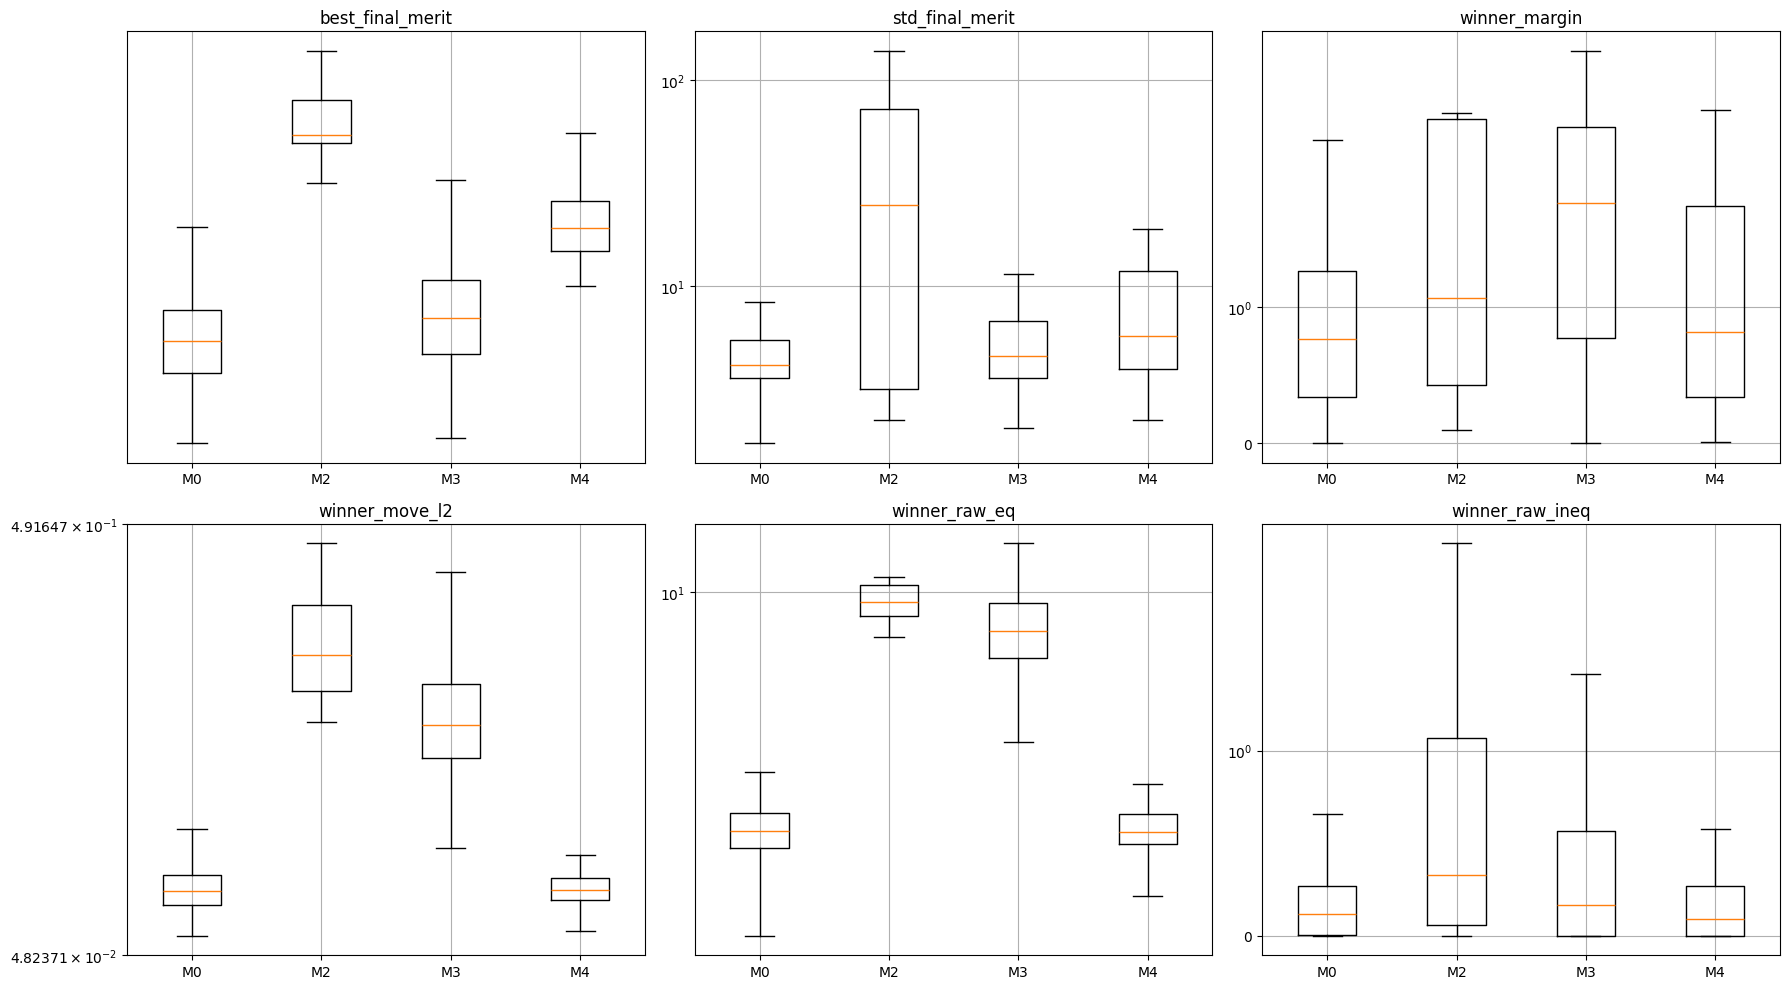

In [39]:
plot_features = [
    'best_final_merit',
    'std_final_merit',
    'winner_margin',
    'winner_move_l2',
    'winner_raw_eq',
    'winner_raw_ineq',
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()
unique_winners = np.unique(winner)

for ax, feat_name in zip(axes, plot_features):
    data = [instance_features[feat_name][winner == m] for m in unique_winners]
    ax.boxplot(data, tick_labels=[f'M{m}' for m in unique_winners], showfliers=False)
    ax.set_title(feat_name)
    ax.set_yscale('symlog' if np.all(np.asarray(instance_features[feat_name]) >= 0) else 'linear')

plt.tight_layout()
plt.show()


Winners with at least 50 samples: [np.int64(0), np.int64(3), np.int64(4)]
Comparing the two most viable winner classes: Member 0 vs Member 3


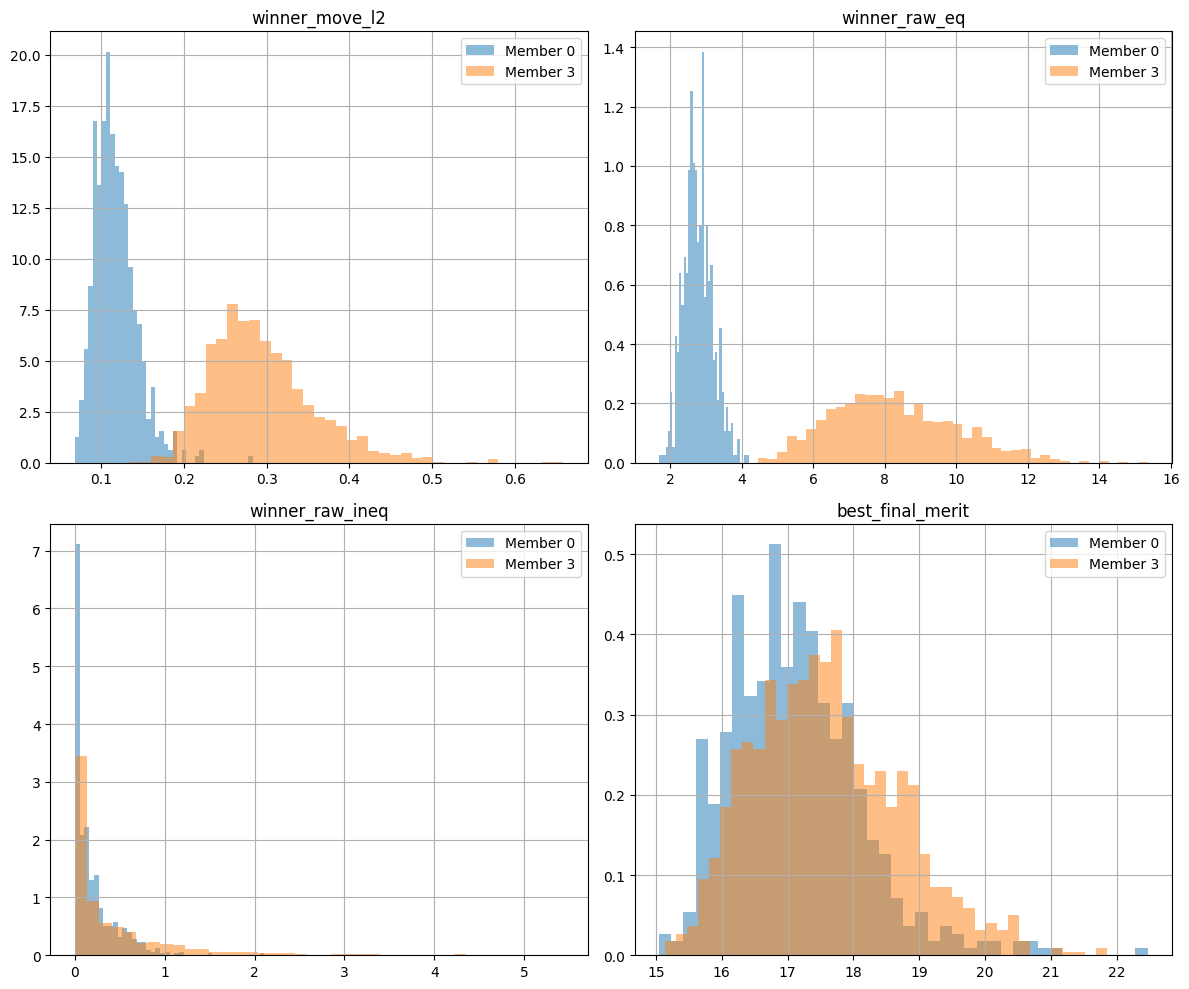

In [40]:
interesting_winners = [m for m in np.unique(winner) if np.sum(winner == m) >= 50]
print('Winners with at least 50 samples:', interesting_winners)

if len(interesting_winners) >= 2:
    ref_a, ref_b = interesting_winners[:2]
    print(f'Comparing the two most viable winner classes: Member {ref_a} vs Member {ref_b}')

    mask = np.isin(winner, [ref_a, ref_b])
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    compare_feats = ['winner_move_l2', 'winner_raw_eq', 'winner_raw_ineq', 'best_final_merit']

    for ax, feat_name in zip(axes.ravel(), compare_feats):
        ax.hist(instance_features[feat_name][winner == ref_a], bins=40, alpha=0.5, density=True, label=f'Member {ref_a}')
        ax.hist(instance_features[feat_name][winner == ref_b], bins=40, alpha=0.5, density=True, label=f'Member {ref_b}')
        ax.set_title(feat_name)
        ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Not enough winner classes with >= 50 samples for a focused pairwise histogram comparison.')


## 11. How to read the diagnostics

A few patterns to watch for:

- If one winner class tends to have much larger `winner_move_l2`, that member may specialize on instances that need more aggressive post-processing.
- If one winner class tends to have much larger `winner_raw_eq` or `winner_raw_ineq`, it may be better on harder feasibility-repair cases.
- If `std_final_merit` or `range_final_merit` is high when a certain member wins, that may mean it shines on instances where members disagree strongly.
- If `best_final_merit` is worse for some winner class, that class may only win on intrinsically harder instances rather than owning a geometric input region.
